# IT Support Dashboard - Supporting Notebook 3

This notebook continues from Notebook 2 by applying text normalisation to the approved English subset. It prepares modelling-ready text features and quantifies recurrence signals for downstream clustering.

## Text Normalisation, Thematic Recurrence Detection, and Actionability

This notebook transforms ticket text into comparable feature representations and measures thematic recurrence before clustering. Additionally, an actionability score is assigned to responsible team's queues, grouped by ticket type.

Methods used:
- `TF-IDF` vectorisation for weighted term representation
- nearest-neighbour `cosine similarity` for recurrence profiling
- `KS` testing for distributional shift after lemmatisation

Value: this stage verifies that normalisation improves lexical consistency without introducing material distortion in global similarity structure.

### Importing

Packages are imported, project directories are validated, and the approved English subset from Notebook 2 is loaded.

Value: this creates a controlled input baseline for all subsequent language transformations and similarity checks.

In [1]:
# Importing essential packages
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import spacy.cli.download as spacy_download
from scipy import sparse
from scipy.stats import gaussian_kde, ks_2samp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# Add project root to sys.path by searching upward for config.py
project_root = next(
	(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists()), None
)
if project_root is None:
	raise FileNotFoundError("Could not locate project root containing config.py")
if str(project_root) not in sys.path:
	sys.path.append(str(project_root))

from config import Config  # noqa: E402

Config.ensure_directories()

# Reading the initial dataset as a DataFrame: df
df = pd.read_parquet(Config.ENGLISH_PARQUET_PATH, engine="pyarrow")

display(df)

[Config] Verified project directory structure under C:\Users\cosmi\Documents\Projects\IT-Support-Ticket-Analysis


,Index,Subject,Body,Answer,Type,Queue,Priority,Language,Version,Tag_1,Tag_2,Tag_3,Tag_4,Tag_5,Tag_6,Tag_7,Tag_8
0,1,Account Disruption,"Dear Customer Support Team, I am writing to re...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,High,EN,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
1,2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team, I hope this messag...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,Medium,EN,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
2,3,Inquiry Regarding Invoice Details,"Dear Customer Support Team, I hope this messag...",We appreciate you reaching out with your billi...,Request,Billing and Payments,Low,EN,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
3,4,Question About Marketing Agency Software Compa...,"Dear Support Team, I hope this message reaches...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,Medium,EN,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN
4,5,Feature Query,"Dear Customer Support, I hope this message rea...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,High,EN,51,Feature,Product,Documentation,Feedback,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13724,28578,Problem with Billing Adjustment,An unexpected billing discrepancy has been not...,We apologize for the billing discrepancy in th...,Incident,Billing and Payments,High,EN,400,Billing,Payment,Performance,Bug,NaN,NaN,NaN,NaN
13725,28580,Urgent: Incident Involving Data Breach in Medi...,"A data breach has occurred, which might be rel...","Dear [Name], we acknowledge the urgency of the...",Problem,Product Support,Medium,EN,400,Security,Incident,Bug,Performance,NaN,NaN,NaN,NaN
13726,28582,Performance Problem with Data Analytics Tool,The data analytics tool experiences sluggish p...,We are addressing the performance issue with t...,Incident,Technical Support,High,EN,400,Performance,IT,Tech Support,NaN,NaN,NaN,NaN,NaN
13727,28585,Update Request for SaaS Platform Integration F...,Requesting an update on the integration featur...,Received your request for updates on the integ...,Change,IT Support,High,EN,400,Feature,IT,Tech Support,NaN,NaN,NaN,NaN,NaN


### Boosting Signal, Reducing Noise

`Subject`, `Body`, and `Answer` are combined into `Combined Text` so each record retains full issue context before normalisation.

Value: this reduces feature fragmentation and improves comparability across tickets.

In [2]:
# Creating a lemmatising text dataframe
lemmatised_text_df = df[
	["Subject", "Body", "Answer", "Type", "Queue", "Priority", "Language", "Version"]
].copy()

# Combining text to boost signal
lemmatised_text_df["Combined Text"] = (
	lemmatised_text_df["Subject"]
	+ " "
	+ lemmatised_text_df["Body"]
	+ " "
	+ lemmatised_text_df["Answer"]
)

# Drop redundant text columns
lemmatised_text_df.drop(
	columns=["Language", "Subject", "Body", "Answer"], inplace=True
)

# Show lemmatised dataframe
display(lemmatised_text_df)

,Type,Queue,Priority,Version,Combined Text
0,Incident,Technical Support,High,51,"Account Disruption Dear Customer Support Team,..."
1,Request,Returns and Exchanges,Medium,51,Query About Smart Home System Integration Feat...
2,Request,Billing and Payments,Low,51,Inquiry Regarding Invoice Details Dear Custome...
3,Problem,Sales and Pre-Sales,Medium,51,Question About Marketing Agency Software Compa...
4,Request,Technical Support,High,51,"Feature Query Dear Customer Support, I hope th..."
...,...,...,...,...,...
13724,Incident,Billing and Payments,High,400,Problem with Billing Adjustment An unexpected ...
13725,Problem,Product Support,Medium,400,Urgent: Incident Involving Data Breach in Medi...
13726,Incident,Technical Support,High,400,Performance Problem with Data Analytics Tool T...
13727,Change,IT Support,High,400,Update Request for SaaS Platform Integration F...


Combined text is then lemmatised so morphological variants (for example, `running`, `ran`, `runs`) map to a shared lemma (`run`).

Value: this improves semantic alignment in vector space while reducing redundant vocabulary variance.

In [3]:
# Lemmatisation using spaCy
try:
	nlp = spacy.load(Config.SPACY_MODEL, disable=["parser", "ner"])
except OSError:
	print(f"spaCy model '{Config.SPACY_MODEL}' not found. Attempting to download...")
	try:
		spacy_download(Config.SPACY_MODEL)
		nlp = spacy.load(Config.SPACY_MODEL, disable=["parser", "ner"])
	except (OSError, ValueError):
		print(
			f"Could not download or load spaCy model '{Config.SPACY_MODEL}'. "
			"Falling back to blank English pipeline."
		)
		nlp = spacy.blank("en")
except ValueError:
	print(f"Invalid spaCy model name: '{Config.SPACY_MODEL}'. Falling back to blank English pipeline.")
	nlp = spacy.blank("en")


def lemmatise_doc(doc) -> str:
	"""Return lemmatised string of alphabetic, non-stopword tokens."""
	return " ".join(
		token.lemma_
		for token in doc
		if not token.is_stop and token.is_alpha and len(token) > 2
	)


# Apply lemmatisation to each record using spaCy's batched pipeline
combined_texts = lemmatised_text_df["Combined Text"].fillna("").tolist()
print("Lemmatising the text with a batched spaCy pipeline (~3-5 mins)...")
lemmatised_text_df["Lemmatised Text"] = [
	lemmatise_doc(doc)
	for doc in nlp.pipe(combined_texts, batch_size=Config.SPACY_BATCH_SIZE)
]

# Measure word-token reduction from lemmatisation
lemmatised_text_df["Tokens Before"] = (
	lemmatised_text_df["Combined Text"].fillna("").str.split().map(len)
)
lemmatised_text_df["Tokens After"] = (
	lemmatised_text_df["Lemmatised Text"].fillna("").str.split().map(len)
)

# Show changes at a glance
display(
	lemmatised_text_df[
		["Combined Text", "Lemmatised Text", "Tokens Before", "Tokens After"]
	]
)

Lemmatising the text with a batched spaCy pipeline (~3-5 mins)...


,Combined Text,Lemmatised Text,Tokens Before,Tokens After
0,"Account Disruption Dear Customer Support Team,...",Account Disruption Dear Customer Support Team ...,169,85
1,Query About Smart Home System Integration Feat...,query Smart Home System Integration feature De...,156,96
2,Inquiry Regarding Invoice Details Dear Custome...,inquiry Invoice detail Dear Customer Support T...,184,101
3,Question About Marketing Agency Software Compa...,question Marketing Agency Software Compatibili...,146,82
4,"Feature Query Dear Customer Support, I hope th...",feature Query Dear Customer Support hope messa...,125,61
...,...,...,...,...
13724,Problem with Billing Adjustment An unexpected ...,problem Billing Adjustment unexpected billing ...,72,36
13725,Urgent: Incident Involving Data Breach in Medi...,Urgent Incident Involving Data Breach Medical ...,122,59
13726,Performance Problem with Data Analytics Tool T...,Performance Problem Data Analytics Tool data a...,59,36
13727,Update Request for SaaS Platform Integration F...,update request SaaS Platform Integration featu...,90,49


### Similarity Comparison

Once vocabulary is represented at concept level rather than surface word-form level, `TF-IDF` can treat related phrasing as shared features rather than fragmented variants. This generally stabilises nearest-neighbour comparisons, while over-normalisation can merge genuinely different meanings.

We therefore validate the transformation with two paired checks:
- `Cosine Similarity`: how close each ticket is to its nearest neighbour
- `Kolmogorov-Smirnov (KS)` test: whether the global similarity distribution shifts after lemmatisation

For downstream reuse, the preferred export is the sparse `vec_lemma.fit_transform(...)` result because it preserves the exact model features and weights while avoiding large dense allocations. This notebook now saves:
- sparse matrix: `Config.TFIDF_SPARSE_MATRIX_PATH`
- feature names: `Config.TFIDF_FEATURE_NAMES_PATH`

A dense parquet snapshot is retained at `Config.TFIDF_MATRIX_PATH` as a compatibility artefact for inspection and legacy reads.

This design keeps modelling sparse by default, preserves reproducibility, and avoids altering matrix values during later analysis steps.

### Cosine Similarity Test

This test computes each ticket's nearest-neighbour similarity before and after lemmatisation.

Value: it measures whether normalisation increases thematic comparability at record level.

In [4]:
# Then, we measured total token reduction from lemmatisation
token_before = lemmatised_text_df["Tokens Before"].sum()
token_after = lemmatised_text_df["Tokens After"].sum()
reduction_pct = 1 - token_after / token_before


def max_similarity(tfidf_matrix):
	"""Return each row's nearest-neighbour cosine similarity (excluding self)."""
	nn_model = NearestNeighbors(n_neighbors=2, metric="cosine", algorithm="brute")
	nn_model.fit(tfidf_matrix)
	distances, _ = nn_model.kneighbors(tfidf_matrix)
	# distances[:, 0] is self-match (0.0); distances[:, 1] is nearest other record.
	return 1.0 - distances[:, 1]


print("Vectorising text in progress (20-180s)...")

# Use shared configuration to keep feature dimensions consistent across notebooks
vec_raw = TfidfVectorizer(
	stop_words="english", max_features=Config.MAX_FEATURES, ngram_range=(1, 2)
)
vec_lemma = TfidfVectorizer(
	stop_words="english", max_features=Config.MAX_FEATURES, ngram_range=(1, 2)
)

# fit_transform returns sparse matrices by default; keep them sparse for modelling
raw_tfidf_matrix = vec_raw.fit_transform(lemmatised_text_df["Combined Text"])
lemma_tfidf_matrix = vec_lemma.fit_transform(lemmatised_text_df["Lemmatised Text"])
feature_names = vec_lemma.get_feature_names_out()

# Save the sparse matrix and feature names for downstream clustering reuse
sparse.save_npz(Config.TFIDF_SPARSE_MATRIX_PATH, lemma_tfidf_matrix)
np.save(Config.TFIDF_FEATURE_NAMES_PATH, feature_names)

# Find nearest-neighbour similarity distributions before vs after lemmatisation
raw_sim = max_similarity(raw_tfidf_matrix)
lemma_sim = max_similarity(lemma_tfidf_matrix)

# Add similarity values to the working dataframe
lemmatised_text_df["Raw Max Similarity"] = raw_sim
lemmatised_text_df["Lemma Max Similarity"] = lemma_sim

# Save lemmatised text, token counts, and max similarity comparison
lemmatised_text_df.to_csv(Config.LEMMA_CSV_PATH, index=False, encoding="utf-8")

# Display key columns
display(
	lemmatised_text_df[
		[
			"Combined Text",
			"Lemmatised Text",
			"Tokens Before",
			"Tokens After",
			"Raw Max Similarity",
			"Lemma Max Similarity",
		]
	]
)

Vectorising text in progress (20-180s)...


,Combined Text,Lemmatised Text,Tokens Before,Tokens After,Raw Max Similarity,Lemma Max Similarity
0,"Account Disruption Dear Customer Support Team,...",Account Disruption Dear Customer Support Team ...,169,85,0.769388,0.796301
1,Query About Smart Home System Integration Feat...,query Smart Home System Integration feature De...,156,96,0.655095,0.613764
2,Inquiry Regarding Invoice Details Dear Custome...,inquiry Invoice detail Dear Customer Support T...,184,101,0.868835,0.906186
3,Question About Marketing Agency Software Compa...,question Marketing Agency Software Compatibili...,146,82,0.833926,0.834966
4,"Feature Query Dear Customer Support, I hope th...",feature Query Dear Customer Support hope messa...,125,61,0.408067,0.400885
...,...,...,...,...,...,...
13724,Problem with Billing Adjustment An unexpected ...,problem Billing Adjustment unexpected billing ...,72,36,0.896822,0.927772
13725,Urgent: Incident Involving Data Breach in Medi...,Urgent Incident Involving Data Breach Medical ...,122,59,0.909368,0.938252
13726,Performance Problem with Data Analytics Tool T...,Performance Problem Data Analytics Tool data a...,59,36,0.717657,0.596063
13727,Update Request for SaaS Platform Integration F...,update request SaaS Platform Integration featu...,90,49,0.874209,0.885953


### Kolmogorov-Smirnov (KS) Test

The `KS` test compares the full distributions of maximum similarity before and after lemmatisation.

Value: it determines whether observed recurrence changes are local tail effects or broad distributional shifts.

In [5]:
# KS test to compare the distributions of max similarities before and after lemmatisation
ks_result = ks_2samp(raw_sim, lemma_sim)
high_similarity_threshold = Config.HIGH_SIMILARITY_THRESHOLD

# Lemmatisation impact summary table
token_reduction_pct = f"{float(reduction_pct) * 100:.2f}%"
raw_sim_mean_pct = f"{(raw_sim >= high_similarity_threshold).mean() * 100:.2f}%"
lemma_sim_mean_pct = f"{(lemma_sim >= high_similarity_threshold).mean() * 100:.2f}%"


summary_rows = [
	("Token reduction", token_reduction_pct),
	("KS statistic", ks_result.statistic),
	("KS p-value", ks_result.pvalue),
	("Mean max similarity (before)", raw_sim.mean()),
	("Mean max similarity (after)", lemma_sim.mean()),
	("Median max similarity (before)", np.median(raw_sim)),
	("Median max similarity (after)", np.median(lemma_sim)),
	(
		f"Share with similarity >= {high_similarity_threshold:.2f} (before)",
		raw_sim_mean_pct,
	),
	(
		f"Share with similarity >= {high_similarity_threshold:.2f} (after)",
		lemma_sim_mean_pct,
	),
]

summary = pd.DataFrame(summary_rows, columns=["Metric", "Value"])

# Saving the summary table to CSV
summary.to_csv(Config.LEMMA_SUMMARY_PATH, index=False, encoding="utf-8")

# Formatting the summary table for better readability
summary_formatted = summary.copy()

summary_formatted.loc[1, "Value"] = f"{summary_formatted.loc[1, 'Value']:.2e}"
summary_formatted.loc[2, "Value"] = f"{summary_formatted.loc[2, 'Value']:.2e}"
summary_formatted.loc[3, "Value"] = f"{summary_formatted.loc[3, 'Value']:.3f}"
summary_formatted.loc[4, "Value"] = f"{summary_formatted.loc[4, 'Value']:.3f}"
summary_formatted.loc[5, "Value"] = f"{summary_formatted.loc[5, 'Value']:.3f}"
summary_formatted.loc[6, "Value"] = f"{summary_formatted.loc[6, 'Value']:.3f}"

print("The Lemmatisation impact summary table:")
display(summary_formatted)

The Lemmatisation impact summary table:


,Metric,Value
0,Token reduction,45.08%
1,KS statistic,1.92e-02
2,KS p-value,1.23e-02
3,Mean max similarity (before),0.733
4,Mean max similarity (after),0.733
5,Median max similarity (before),0.802
6,Median max similarity (after),0.805
7,Share with similarity >= 0.85 (before),36.11%
8,Share with similarity >= 0.85 (after),37.83%


#### Similarity Testing Insights

Lemmatisation reduced token volume substantially while preserving overall similarity geometry.

Key outcome: practical change is concentrated in the high-similarity tail rather than across the full distribution.

Value: this supports retaining lemmatisation for recurrence analysis and downstream clustering.

### KDE Plot

A kernel density view is produced to compare similarity profiles before and after lemmatisation.

Value: this gives a visual check of where distribution changes concentrate, complementing the statistical tests.


KDE plot of similarity distributions:


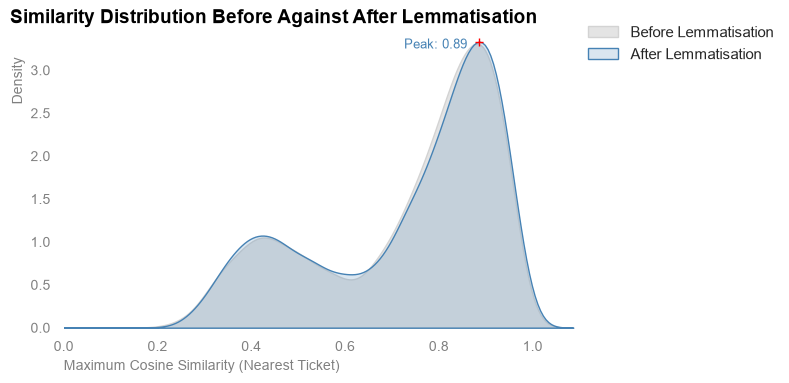

In [6]:
# Lemmatisation impact density plot
sns.set_theme(style="white")

# Initialise the matplotlib figure
f, ax = plt.subplots(figsize=(8, 4))

sns.kdeplot(
	raw_sim, label="Before Lemmatisation", color="lightgrey", fill=True, alpha=0.6
)
sns.kdeplot(
	lemma_sim, label="After Lemmatisation", color="steelblue", fill=True, alpha=0.2
)

# Add a marker at the highest density point of the lemma_sim KDE
kde = gaussian_kde(lemma_sim)
x_vals = np.linspace(lemma_sim.min(), lemma_sim.max(), 1000)
y_vals = kde(x_vals)
peak_x = x_vals[np.argmax(y_vals)]
peak_y = y_vals.max()

ax.annotate(
	f"Peak: {peak_x:.2f}",
	xy=(peak_x, peak_y),
	xytext=(peak_x - 0.16, peak_y - 0.08),
	fontsize=9,
	color="steelblue",
)
ax.plot(peak_x, peak_y, "+", color="red", markersize=6)

# Clean borders: remove top/right spines
sns.despine(left=True, top=True, bottom=True, right=True)

# Set labels and markers to grey for subtlety
ax.set_xlabel("Maximum Cosine Similarity (Nearest Ticket)", color="grey")
ax.set_ylabel("Density", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_fontsize(10)
ax.xaxis.label.set_fontsize(10)
ax.tick_params(labelsize=10)

# Remove horizontal padding so the line starts at the y-axis
ax.set_xlim(lemma_sim.min())

# Set axis alignment and position to the left for better aesthetics
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 0.9))

# Title parameters
ax.set_title(
	"Similarity Distribution Before Against After Lemmatisation",
	fontsize=14,
	fontweight="bold",
	color="black",
	pad=3,
	loc="left",
	x=-0.1,
)

# Move legend to the right side of the plot
ax.legend(bbox_to_anchor=(0.95, 1.05), loc="upper left", edgecolor="white")

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(Config.KDE_PATH, dpi=300, bbox_inches="tight")
print("\nKDE plot of similarity distributions:")
plt.show()

The KDE peak near the upper similarity range indicates concentration of highly similar records after lemmatisation.

Value: this is interpreted together with thresholded tail metrics, not as standalone evidence of duplicate prevalence.

### Quantifying The Right Tail

This section measures ticket shares above configured high-similarity thresholds (`Config.RIGHT_TAIL_THRESHOLDS`).

Value: it quantifies recurrence in the exact region used for downstream prioritisation logic.


Right-tail similarity proportions:


,Threshold,Proportion
0,0.85,0.378
1,0.90,0.206
2,0.95,0.050



Proportion of tickets exceeding high-similarity thresholds:


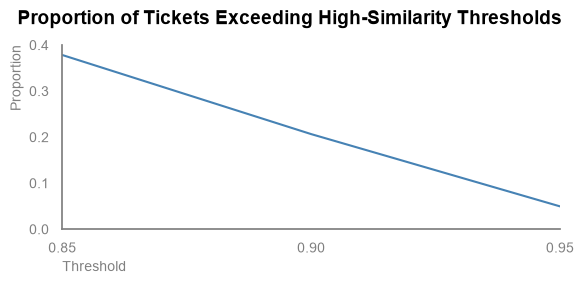

In [7]:
# Quantifying right-tail effect
right_tail_thresholds = Config.RIGHT_TAIL_THRESHOLDS
right_tail_stats = []

for threshold in right_tail_thresholds:
	prop = (lemmatised_text_df["Lemma Max Similarity"] >= threshold).mean()
	right_tail_stats.append({"Threshold": threshold, "Proportion": prop})

right_tail_df = pd.DataFrame(right_tail_stats)
print("\nRight-tail similarity proportions:")
display(right_tail_df.style.format({"Threshold": "{:.2f}", "Proportion": "{:.3f}"}))

# Visualise the cumulative tail effect
# Initialise the matplotlib figure
f, ax = plt.subplots(figsize=(6, 3))

sns.lineplot(data=right_tail_df, x="Threshold", y="Proportion", color="steelblue")

# Set x-axis ticks to the discrete threshold values
ax.set_xticks(right_tail_thresholds)

# Remove horizontal padding so the line starts at the y-axis
ax.set_xlim(
	right_tail_df["Threshold"].min(),
	right_tail_df["Threshold"].max(),
)

# Set y-axis ticks to fit the proportion values
ax.set_yticks(np.linspace(0, 0.4, 5))

# Clean borders: remove top/right spines
sns.despine(ax=ax)

# Set labels and markers to grey for subtlety
ax.set_xlabel("Threshold", color="grey")
ax.set_ylabel("Proportion", color="grey")
ax.tick_params(colors="grey")

# Set the axis lines to grey for better aesthetics
ax.spines["left"].set_color("grey")
ax.spines["bottom"].set_color("grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_fontsize(10)
ax.xaxis.label.set_fontsize(10)
ax.tick_params(labelsize=10)

# Set axis alignment and position to the left for better aesthetics
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Title parameters
ax.set_title(
	"Proportion of Tickets Exceeding High-Similarity Thresholds",
	fontsize=14,
	fontweight="bold",
	color="black",
	pad=15,
	loc="left",
	x=-0.09,
)

plt.tight_layout()
plt.savefig(Config.RIGHT_TAIL_PATH, dpi=300, bbox_inches="tight")

print("\nProportion of tickets exceeding high-similarity thresholds:")
plt.show()

### Category Recurrence

Tickets are grouped by `Type - Queue`, and recurrence is estimated as the share with nearest-neighbour similarity at or above the configured threshold.

Value: this identifies operational categories with concentrated repeat issue patterns.

In [11]:
# Creating a combined 'Type - Queue' column for grouping
threshold = Config.HIGH_SIMILARITY_THRESHOLD
records = []

# Loop through categories and compute within-group nearest-neighbour recurrence
for (type_name, queue_name), group in lemmatised_text_df.groupby(["Type", "Queue"], sort=False):
	type_name = str(type_name)
	queue_name = str(queue_name)

	tfidf_sub = vec_lemma.transform(group["Lemmatised Text"])
	if tfidf_sub.shape[0] < 2:
		recurrence = 0.0
	else:
		max_similarity_values = max_similarity(tfidf_sub)
		recurrence = float((max_similarity_values >= threshold).mean())

	records.append(
		{
			"Type": type_name,
			"Queue": queue_name,
			"Group Size": len(group),
			"Recurrence Rate": recurrence,
		}
	)

category_recurrence_df = pd.DataFrame(records)

# Calculate impact score by combining recurrence concentration and queue volume
category_recurrence_df["Impact Score"] = Config.IMPACT_SCORE_RECURRENCE_WEIGHT * (
	category_recurrence_df["Recurrence Rate"]
	/ category_recurrence_df["Recurrence Rate"].max()
) + Config.IMPACT_SCORE_VOLUME_WEIGHT * (
	category_recurrence_df["Group Size"] / category_recurrence_df["Group Size"].max()
)

# Rank by impact score
category_recurrence_df = category_recurrence_df.sort_values(
	"Impact Score", ascending=False
)

category_recurrence_df["Actionable"] = (
	category_recurrence_df["Impact Score"] > Config.ACTIONABILITY_THRESHOLD
)

# Save category recurrence table
category_recurrence_df.to_csv(
	Config.CAT_RECURRENCE_CSV_PATH, index=False, encoding="utf-8"
)

# Show recurrence rates
display(
	category_recurrence_df.style.format(
		{"Recurrence Rate": "{:.3f}", "Group Size": "{:,}", "Impact Score": "{:.3f}"}
	)
)

,Type,Queue,Group Size,Recurrence Rate,Impact Score,Actionable
2,Request,Billing and Payments,657,0.610,0.653,True
0,Incident,Technical Support,"2,053",0.280,0.640,True
28,Change,Billing and Payments,86,0.698,0.617,True
9,Request,Customer Service,926,0.490,0.602,True
4,Request,Technical Support,815,0.501,0.589,True
36,Request,Human Resources,88,0.659,0.584,True
27,Request,Sales and Pre-Sales,209,0.565,0.526,True
8,Request,Product Support,580,0.467,0.515,True
17,Change,General Inquiry,57,0.579,0.509,True
6,Incident,Product Support,"1,181",0.310,0.497,False


### Category Recurrence Visuals

Recurrence patterns are visualised by `Type` and `Queue`.

Value: these visuals summarise where repeat themes cluster, supporting prioritisation discussions with non-technical stakeholders.

In [12]:
# Apply Seaborn theme globally
sns.set_theme(style="white")

# Order queues by mean impact score (ascending so highest appears at top)
queue_order = (
	category_recurrence_df.groupby("Queue")["Impact Score"]
	.mean()
	.sort_values(ascending=False)
	.index.tolist()
)


Barplot of Impact Score by Queue and Type:


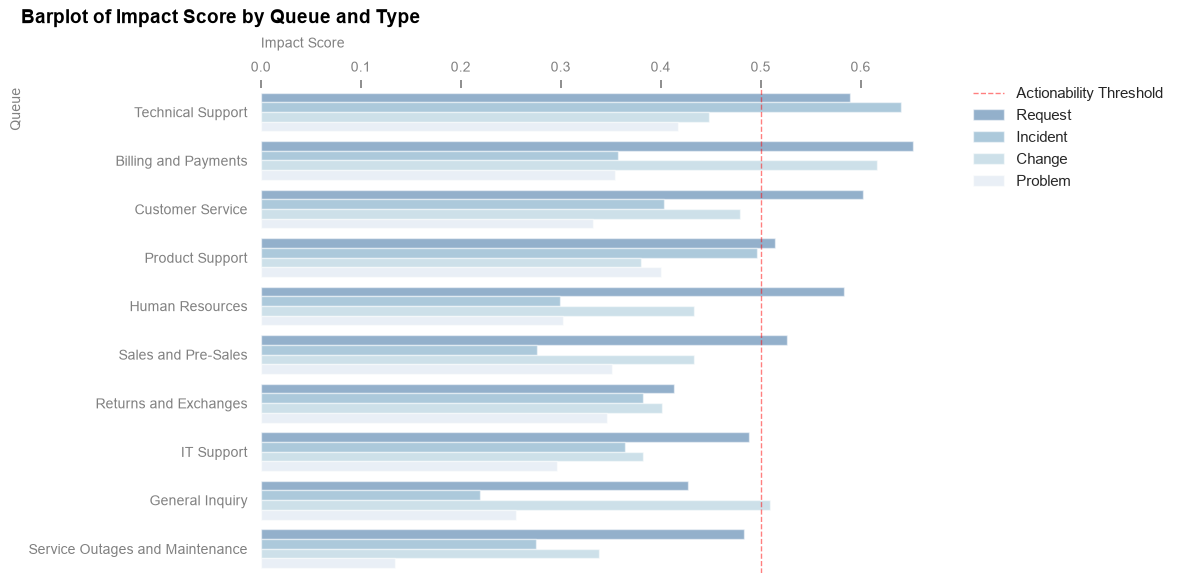

In [13]:
# Horizontal barplot of impact score by queue over type
# Initialise the matplotlib figure
f, ax = plt.subplots(figsize=(12, 6))

ax.axvline(
	x=Config.ACTIONABILITY_THRESHOLD,
	color="red",
	linestyle="--",
	linewidth=1,
	alpha=0.5,
	label="Actionability Threshold",
)

# Plot higher-impact points in colour by type
sns.barplot(
	data=category_recurrence_df,
	x="Impact Score",
	y="Queue",
	hue="Type",
	palette="Blues_r",
	alpha=0.5,
	order=queue_order,
)

# Clean borders by removing bottom/right spines
sns.despine(left=True, top=True, bottom=True, right=True)

# Set labels and markers to grey for subtlety
ax.set_xlabel("Impact Score", color="grey")
ax.set_ylabel("Queue", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_fontsize(10)
ax.xaxis.label.set_fontsize(10)
ax.tick_params(labelsize=10)

# X-axis on top for better readability
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1.3))
ax.xaxis.labelpad = 10  # Add padding to the x-axis label for better spacing

# Y-axis label alignment and position for better aesthetics
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Set title with font size 14 and grey colour for subtlety
ax.set_title(
	"Barplot of Impact Score by Queue and Type",
	fontsize=14,
	fontweight="bold",
	color="black",
	pad=10,
	loc="left",
	x=-0.35,
)

# Move legend to the right side of the plot
ax.legend(bbox_to_anchor=(1.02, 1.03), loc="upper left", edgecolor="white")

plt.tight_layout()
plt.savefig(Config.IMPACT_BARPLOT_PATH, dpi=300, bbox_inches="tight")

print("\nBarplot of Impact Score by Queue and Type:")
plt.show()


Lineplot of Impact Score by Queue and Type:


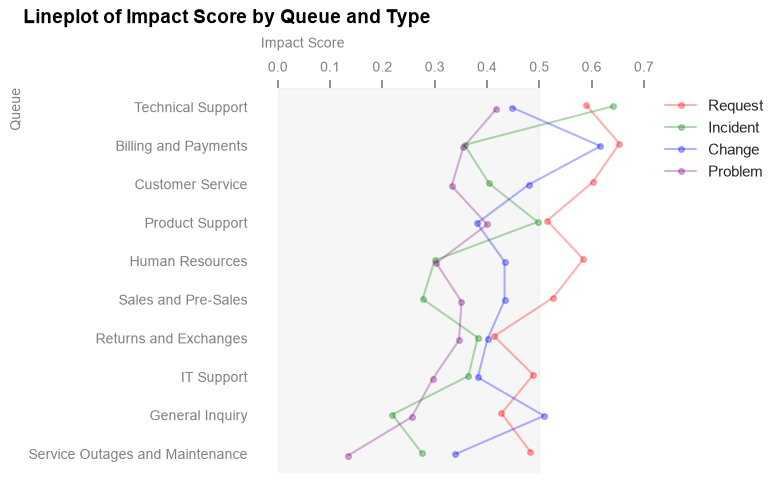

In [14]:
# Visualising the category recurrence rates with a line plot
# Initialise the matplotlib figure
f, ax = plt.subplots(figsize=(8, 5))

sns.pointplot(
	data=category_recurrence_df,
	y="Queue",
	x="Impact Score",
	hue="Type",
	order=queue_order,
	palette={
		"Request": "red",
		"Incident": "green",
		"Problem": "purple",
		"Change": "blue",
	},
	dodge=True,
	markers="o",
	markersize=4,
	linestyles="-",
	linewidth=1.5,
	alpha=0.3,
)

# Shade the area below the actionability threshold
ax.axvspan(
	color="lightgrey",
	alpha=0.2,
	zorder=0,
	xmin=0,
	xmax=Config.ACTIONABILITY_THRESHOLD,
)

# Clean borders by removing bottom/right spines
sns.despine(left=True, top=True, bottom=True, right=True)

ax.xaxis.set_ticks(np.arange(0, 0.71, 0.1))

# Set labels and markers to grey for subtlety
ax.set_xlabel("Impact Score", color="grey")
ax.set_ylabel("Queue", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_fontsize(10)
ax.xaxis.label.set_fontsize(10)
ax.tick_params(labelsize=10)

# X-axis on top for better readability
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.xaxis.labelpad = 10

# Y-axis label alignment and position for better aesthetics
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Set title
ax.set_title(
	"Lineplot of Impact Score by Queue and Type",
	fontsize=14,
	fontweight="bold",
	color="black",
	pad=10,
	loc="left",
	x=-0.62,
)

# Move legend to the right side of the plot
ax.legend(bbox_to_anchor=(1.02, 1.005), loc="upper left", edgecolor="white")

plt.tight_layout()
plt.savefig(Config.IMPACT_LINEPLOT_PATH, dpi=300, bbox_inches="tight")

print("\nLineplot of Impact Score by Queue and Type:")
plt.show()


Dotplot of Impact Score by Queue and Type:


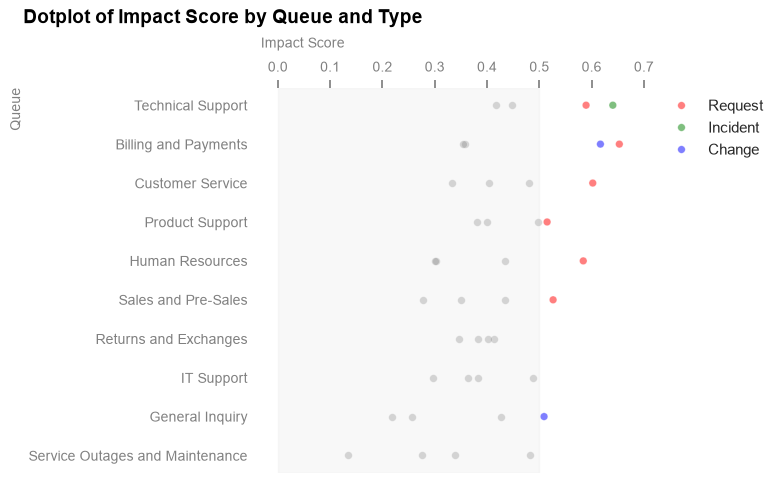

In [15]:
# Dotplot of impact score by queue and type
# Initialise the matplotlib figure
f, ax = plt.subplots(figsize=(8, 5))

# Anchor all queue positions in the desired order before plotting real data
sns.scatterplot(x=[0.0] * len(queue_order), y=queue_order, alpha=0, s=0)

# Build boolean masks once for readable filtering
actionable_mask = category_recurrence_df["Actionable"].astype(bool)
non_actionable_mask = ~actionable_mask

# Plot lower-impact points in grey
sns.scatterplot(
	data=category_recurrence_df[non_actionable_mask],
	x="Impact Score",
	y="Queue",
	color="grey",
	alpha=0.3,
	s=30,
	legend=False,
)

# Plot higher-impact points in colour by type
sns.scatterplot(
	data=category_recurrence_df[actionable_mask],
	x="Impact Score",
	y="Queue",
	hue="Type",
	palette={
		"Change": "blue",
		"Request": "red",
		"Incident": "green",
		"Problem": "purple",
	},
	alpha=0.5,
	s=30,
)

# Shade the area below the actionability threshold
ax.axvspan(
	color="lightgrey",
	alpha=0.15,
	zorder=0,
	xmin=0,
	xmax=Config.ACTIONABILITY_THRESHOLD,
)

# Clean borders by removing bottom/right spines
sns.despine(left=True, top=True, bottom=True, right=True)

ax.xaxis.set_ticks(np.arange(0, 0.71, 0.1))

# Set labels and markers to grey for subtlety
ax.set_xlabel("Impact Score", color="grey")
ax.set_ylabel("Queue", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_fontsize(10)
ax.xaxis.label.set_fontsize(10)
ax.tick_params(labelsize=10)

# X-axis on top for better readability
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.xaxis.labelpad = 10

# Y-axis label alignment and position for better aesthetics
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Set title
ax.set_title(
	"Dotplot of Impact Score by Queue and Type",
	fontsize=14,
	fontweight="bold",
	color="black",
	pad=10,
	loc="left",
	x=-0.62,
)

# Move legend to the right side of the plot
ax.legend(bbox_to_anchor=(1.02, 1.005), loc="upper left", edgecolor="white")

plt.tight_layout()
plt.savefig(Config.IMPACT_DOTPLOT_PATH, dpi=300, bbox_inches="tight")

print("\nDotplot of Impact Score by Queue and Type:")
plt.show()

### Findings

#### Statistical Effect Of Lemmatisation

Lemmatisation reduced token count materially while preserving overall similarity structure.

Key reported metrics:
- `KS statistic`
- `KS p-value`
- mean and median nearest-neighbour similarity before versus after
- share above high-similarity thresholds

Interpretation: the main practical gain is improved concentration in the high-similarity tail, not a broad redistribution of the full similarity profile.

#### Operational Recurrence Profile

Right-tail and category-level recurrence results show where repeat themes are most concentrated across `Type` and `Queue`.

Value: this provides the empirical bridge from text normalisation to cluster construction.

Handoff to Notebook 4: sparse `TF-IDF` features and recurrence evidence are used to build and prioritise issue clusters.